In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Load JSON results from both models
with open("results_old.json", "r") as f:
    old = json.load(f)

with open("results_new.json", "r") as f:
    new = json.load(f)

print("Old model results:", list(old.keys()))
print("New model results:", list(new.keys()))


Old model results: ['raw', 'five', 'quarter', 'hourly', 'daily']
New model results: ['five', 'quarter', 'hourly', 'daily']


In [3]:
# Convert to DataFrame for easier analysis
df_old = pd.DataFrame(old).T
df_new = pd.DataFrame(new).T

# Remove raw data since mesonet only starts from five minute aggregation
keep = ["five", "quarter", "hourly", "daily"]

df_old = df_old.loc[keep]
df_new = df_new.loc[keep]

print("\nNYISO-only model metrics:")
print(df_old)
print("\nNYISO + Mesonet model metrics:")
print(df_new)



NYISO-only model metrics:
             MAPE        MAE        RMSE        R2     Time_s
five     0.368621   5.607673    7.602286  0.999267  26.897943
quarter  0.474673   7.451778   10.108995  0.998703  10.254274
hourly   2.695155  42.067543   53.786694  0.963164   1.482005
daily    4.767556  74.856337  100.507694  0.800068   0.183642

NYISO + Mesonet model metrics:
             MAPE        MAE       RMSE        R2     Time_s
five     0.266953   4.158548   5.862341  0.999564  23.299917
quarter  0.371482   5.812136   8.038237  0.999180   9.964123
hourly   1.633565  24.975142  32.835167  0.986254   4.643449
daily    3.111464  48.435586  65.426056  0.914055   1.053383


In [4]:
# Calculate improvement percentages
improvement = pd.DataFrame(index=keep)

for metric in ["MAPE", "MAE", "RMSE"]:
    # For these metrics, lower is better
    improvement[f"{metric}_improvement_%"] = ((df_old[metric] - df_new[metric]) / df_old[metric] * 100)

# For R², higher is better
improvement["R2_improvement_%"] = ((df_new["R2"] - df_old["R2"]) / df_old["R2"] * 100)

print("\nImprovement from adding Mesonet weather data:")
print(improvement.round(2))



Improvement from adding Mesonet weather data:
         MAPE_improvement_%  MAE_improvement_%  RMSE_improvement_%  \
five                  27.58              25.84               22.89   
quarter               21.74              22.00               20.48   
hourly                39.39              40.63               38.95   
daily                 34.74              35.30               34.90   

         R2_improvement_%  
five                 0.03  
quarter              0.05  
hourly               2.40  
daily               14.25  


## Comparison Plots
Visualize performance metrics across different time aggregations

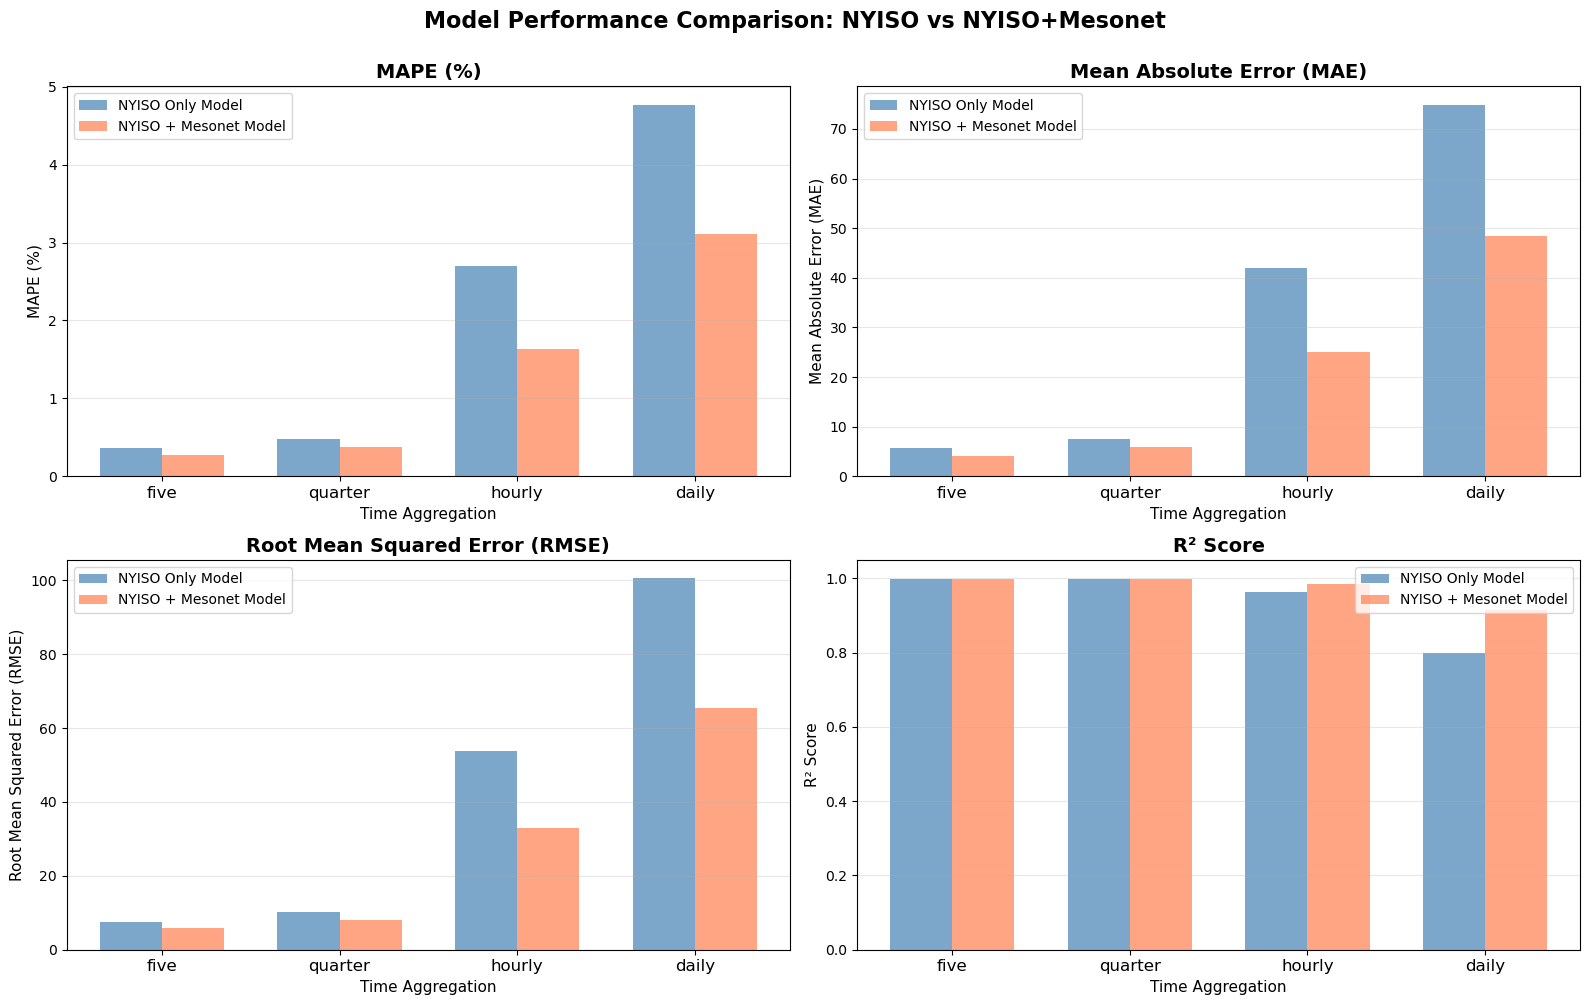

In [5]:
metrics = ["MAPE", "MAE", "RMSE", "R2"]
titles = {
    "MAPE": "MAPE (%)",
    "MAE":  "Mean Absolute Error (MAE)",
    "RMSE": "Root Mean Squared Error (RMSE)",
    "R2":   "R² Score"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

x = np.arange(len(keep))  # positions
bar_width = 0.35

for i, metric in enumerate(metrics):
    ax = axes[i]

    old_vals = df_old[metric].values
    new_vals = df_new[metric].values

    bars1 = ax.bar(x - bar_width/2, old_vals, width=bar_width, 
                   label="NYISO Only Model", alpha=0.7, color='steelblue')
    bars2 = ax.bar(x + bar_width/2, new_vals, width=bar_width, 
                   label="NYISO + Mesonet Model", alpha=0.7, color='coral')

    ax.set_title(titles[metric], fontsize=14, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(keep, fontsize=12)
    ax.set_xlabel("Time Aggregation", fontsize=11)
    ax.set_ylabel(titles[metric], fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    # Improve spacing for tight metrics
    if metric == "R2":
        ax.set_ylim(0, 1.05)

    ax.legend(loc='best')

plt.suptitle("Model Performance Comparison: NYISO vs NYISO+Mesonet", 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


## Summary Statistics

In [6]:
# Calculate average improvement across all aggregations
avg_improvement = improvement.mean()
print("Average improvement across all time aggregations:")
print(avg_improvement.round(2))

# Find best performing aggregation for each model
print("\n" + "="*60)
print("Best performing time aggregation:")
print("="*60)
for metric in ["MAPE", "MAE", "RMSE"]:
    old_best = df_old[metric].idxmin()
    new_best = df_new[metric].idxmin()
    print(f"{metric}:")
    print(f"  NYISO-only: {old_best} ({df_old.loc[old_best, metric]:.4f})")
    print(f"  + Mesonet:  {new_best} ({df_new.loc[new_best, metric]:.4f})")

# R² - higher is better
old_best = df_old["R2"].idxmax()
new_best = df_new["R2"].idxmax()
print(f"R²:")
print(f"  NYISO-only: {old_best} ({df_old.loc[old_best, 'R2']:.4f})")
print(f"  + Mesonet:  {new_best} ({df_new.loc[new_best, 'R2']:.4f})")


Average improvement across all time aggregations:
MAPE_improvement_%    30.86
MAE_improvement_%     30.94
RMSE_improvement_%    29.31
R2_improvement_%       4.18
dtype: float64

Best performing time aggregation:
MAPE:
  NYISO-only: five (0.3686)
  + Mesonet:  five (0.2670)
MAE:
  NYISO-only: five (5.6077)
  + Mesonet:  five (4.1585)
RMSE:
  NYISO-only: five (7.6023)
  + Mesonet:  five (5.8623)
R²:
  NYISO-only: five (0.9993)
  + Mesonet:  five (0.9996)


In [7]:
# Create detailed comparison table
comparison_table = pd.DataFrame()
for metric in metrics:
    comparison_table[f"{metric}_old"] = df_old[metric]
    comparison_table[f"{metric}_new"] = df_new[metric]
    if metric in ["MAPE", "MAE", "RMSE"]:
        comparison_table[f"{metric}_Δ%"] = improvement[f"{metric}_improvement_%"]
    else:
        comparison_table[f"{metric}_Δ%"] = improvement[f"{metric}_improvement_%"]

print("\nDetailed Comparison Table:")
print(comparison_table.round(4))

# Save to CSV
comparison_table.to_csv("model_comparison_detailed.csv")
print("\nSaved detailed comparison to: model_comparison_detailed.csv")



Detailed Comparison Table:
         MAPE_old  MAPE_new  MAPE_Δ%  MAE_old  MAE_new   MAE_Δ%  RMSE_old  \
five       0.3686    0.2670  27.5805   5.6077   4.1585  25.8418    7.6023   
quarter    0.4747    0.3715  21.7394   7.4518   5.8121  22.0034   10.1090   
hourly     2.6952    1.6336  39.3888  42.0675  24.9751  40.6309   53.7867   
daily      4.7676    3.1115  34.7367  74.8563  48.4356  35.2953  100.5077   

         RMSE_new  RMSE_Δ%  R2_old  R2_new    R2_Δ%  
five       5.8623  22.8871  0.9993  0.9996   0.0297  
quarter    8.0382  20.4843  0.9987  0.9992   0.0477  
hourly    32.8352  38.9530  0.9632  0.9863   2.3973  
daily     65.4261  34.9044  0.8001  0.9141  14.2472  

Saved detailed comparison to: model_comparison_detailed.csv
